In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, matthews_corrcoef
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split

In [3]:
#for colab
uploaded = files.upload()

Saving adapted_cas_lab.csv to adapted_cas_lab.csv


In [4]:
df = pd.read_csv('adapted_cas_lab.csv')

**ds inspection**

In [5]:
print(df.head())
#well the first few are all the same

   Numberofports  Numberofnets  Numberofcells  Numberofsequentialcells  \
0          26623        198177         172368                     6850   
1          26623        198177         172368                     6850   
2          26623        198177         172368                     6850   
3          26623        198177         172368                     6850   
4          26623        198177         172368                     6850   

   Numberofreferences  NetSwitchingPower  TotalDynamicPower  \
0                  22            38.9455            84.5052   
1                  22            38.9455            84.5052   
2                  22            38.9455            84.5052   
3                  22            38.9455            84.5052   
4                  22            38.9455            84.5052   

   CombinationalSwitchingPower  CombinationalTotalPower  TotalSwitchingPower  \
0                      32696.0                  56082.0              38947.0   
1               

In [6]:
print(f"Total rows: {len(df)}")
print(f"Unique rows: {df.drop_duplicates().shape[0]}")
#a lot of similar rows as well

Total rows: 1747
Unique rows: 879


In [7]:
#missing v
print(df.isnull().sum())

Numberofports                  0
Numberofnets                   0
Numberofcells                  0
Numberofsequentialcells        0
Numberofreferences             0
NetSwitchingPower              0
TotalDynamicPower              0
CombinationalSwitchingPower    0
CombinationalTotalPower        0
TotalSwitchingPower            0
TotalTotalPower                0
label                          0
dtype: int64


In [8]:
# Class distribution
print("Class distribution (1 = Trojan, 0 = Benign)")
print(df['label'].value_counts())
#fairly balanced

Class distribution (1 = Trojan, 0 = Benign)
label
1    885
0    862
Name: count, dtype: int64


In [9]:
#general statistics
print(df.describe().T)

                              count         mean           std       min  \
Numberofports                1747.0   907.706354   4289.771386   26.0000   
Numberofnets                 1747.0  7915.896394  30907.829534  134.0000   
Numberofcells                1747.0  6905.767602  27017.512047   91.0000   
Numberofsequentialcells      1747.0  2893.248426   7354.789000   39.0000   
Numberofreferences           1747.0    19.412707     14.382108    1.0000   
NetSwitchingPower            1747.0   150.495697    181.131950    1.7034   
TotalDynamicPower            1747.0   151.029572    179.605125    1.1358   
CombinationalSwitchingPower  1747.0   982.211711   5014.270409    2.2500   
CombinationalTotalPower      1747.0  1546.385366   8583.723346    6.0595   
TotalSwitchingPower          1747.0  1132.670643   5966.485661   19.9124   
TotalTotalPower              1747.0  2377.778620  13808.874470   19.9124   
label                        1747.0     0.506583      0.500100    0.0000   

           

In [10]:
#spotting outliers with interqurtile distance
def detect_outliers_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return outliers

print("\n Outlier counts per feature:")
outlier_summary = {}

for col in df.drop(columns='label').columns:
    n_outliers = detect_outliers_iqr(df, col).shape[0]
    outlier_summary[col] = n_outliers

# Display as DataFrame
outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['# Outliers'])
print(outlier_df.sort_values(by='# Outliers', ascending=False))

#*/1748 , lot of, maybe l ll indagate better at some point or try to drop.


 Outlier counts per feature:
                             # Outliers
Numberofnets                        202
TotalTotalPower                     202
Numberofcells                       198
CombinationalSwitchingPower         196
TotalSwitchingPower                 196
CombinationalTotalPower             196
Numberofsequentialcells             194
NetSwitchingPower                   140
TotalDynamicPower                   138
Numberofports                        61
Numberofreferences                    0


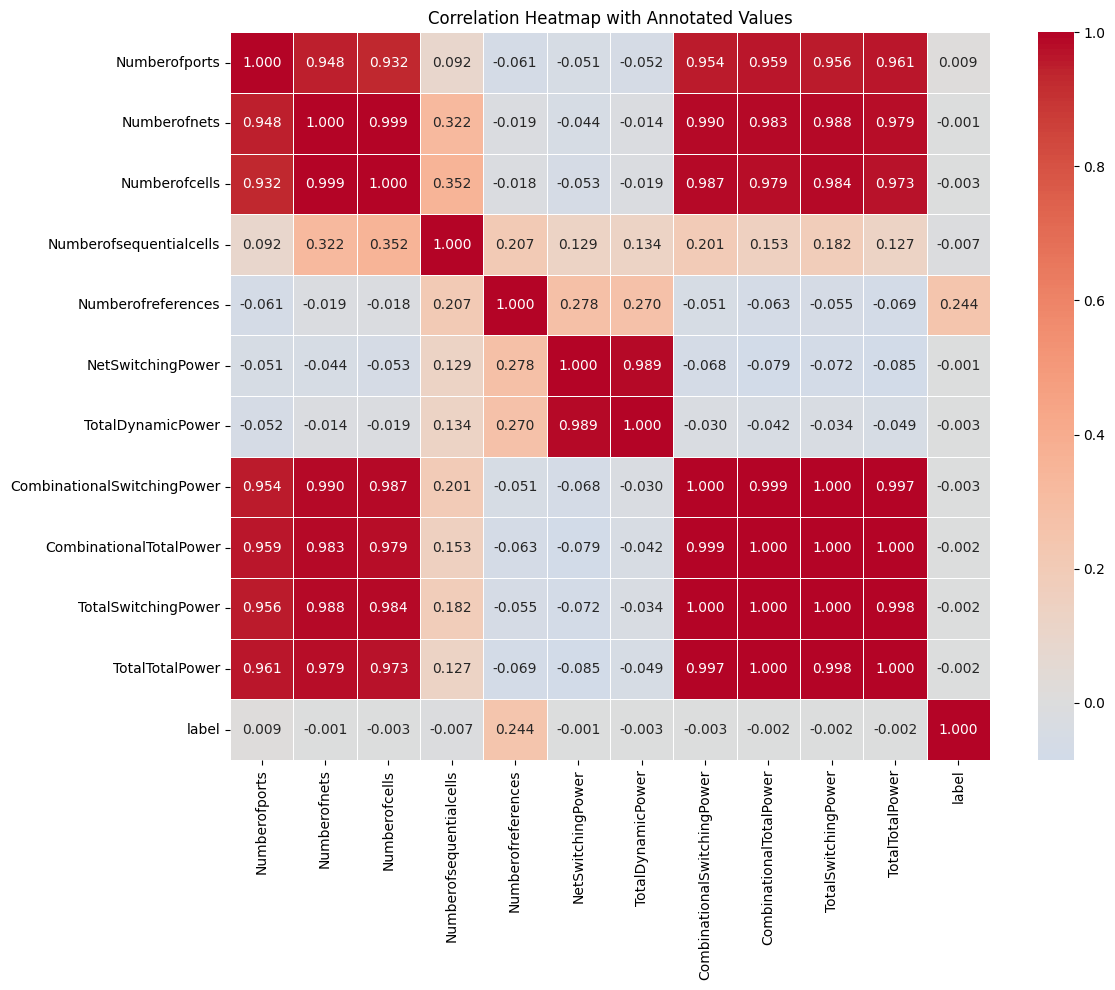

In [11]:
#correlation heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation Heatmap with Annotated Values")
plt.tight_layout()
plt.show()
#label is low correlation with everything, only one more promising is Numberofreferences,l
#some features are linear combination of others and usually are excluded as they increment confusion without adding to the prediction

In [12]:
#feature selection
selected_columns = ['Numberofports', 'Numberofreferences', 'Numberofsequentialcells', 'label']

# create reduced dataset
df2 = df[selected_columns].copy()

In [13]:
#Split
X = df.drop(columns='label')
y = df['label']
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_test, X_eval, y_test, y_eval = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

X2 = df2.drop(columns='label')
y2 = df2['label']
X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X2, y2, test_size=0.30, stratify=y, random_state=42
)
X2_test, X2_eval, y2_test, y2_eval = train_test_split(
    X2_temp, y2_temp, test_size=0.50, stratify=y2_temp, random_state=42
)

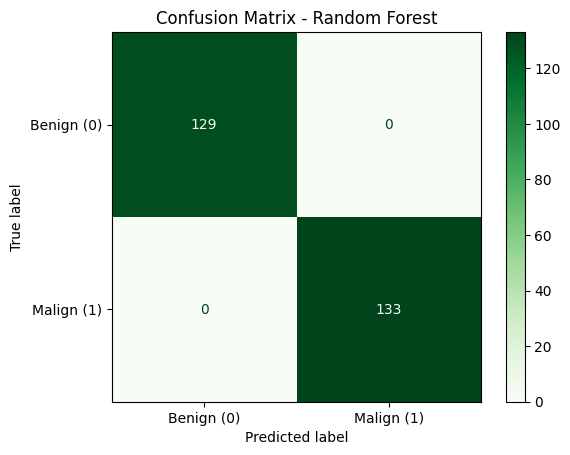

Matthews Correlation Coefficient: 1.0000

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       129
      Malign       1.00      1.00      1.00       133

    accuracy                           1.00       262
   macro avg       1.00      1.00      1.00       262
weighted avg       1.00      1.00      1.00       262



In [14]:
#model 1
#rf was chosen as it performed better on the other similar task. Also since correlation is very low it is to be expected that all the model based on correlation wont perform very well
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
#predict
y_pred = rf.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign (0)", "Malign (1)"])
disp.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Random Forest")
plt.show()

# mcc
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient: {mcc:.4f}")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malign"]))

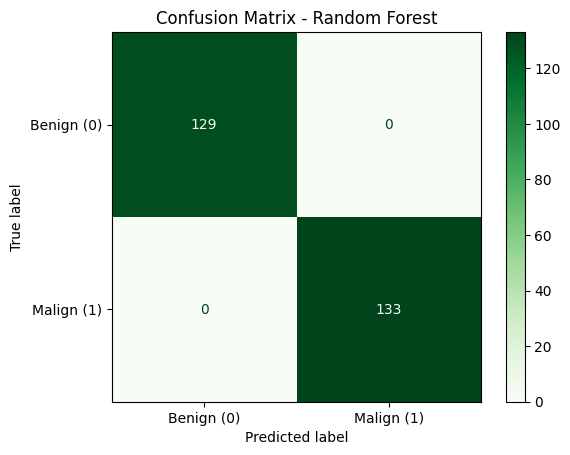

Matthews Correlation Coefficient (MCC): 1.0000

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       129
      Malign       1.00      1.00      1.00       133

    accuracy                           1.00       262
   macro avg       1.00      1.00      1.00       262
weighted avg       1.00      1.00      1.00       262



In [15]:
#model feature selected
rf2 = RandomForestClassifier(random_state=42)
rf2.fit(X2_train, y2_train)
#predict
y2_pred = rf2.predict(X2_test)

# Confusion Matrix
cm2 = confusion_matrix(y2_test, y2_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["Benign (0)", "Malign (1)"])
disp2.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Random Forest")
plt.show()

# MCC
mcc2 = matthews_corrcoef(y2_test, y2_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc2:.4f}")

# Full classification report
print("\nClassification Report:")
print(classification_report(y2_test, y2_pred, target_names=["Benign", "Malign"]))

In [16]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).head(10))
#as predicted one feature is way more important than the other, considering also a lot of rows are duplicated, the task is trivialized and the model obtain a perfect score

Numberofreferences             0.298953
Numberofsequentialcells        0.096467
Numberofnets                   0.094085
CombinationalSwitchingPower    0.075189
CombinationalTotalPower        0.074856
TotalDynamicPower              0.072155
TotalSwitchingPower            0.069383
NetSwitchingPower              0.066179
TotalTotalPower                0.065313
Numberofcells                  0.064819
dtype: float64


In [21]:
importances2 = pd.Series(rf2.feature_importances_, index=X2.columns)
print(importances2.sort_values(ascending=False).head(3))

Numberofreferences         0.519783
Numberofsequentialcells    0.332245
Numberofports              0.147972
dtype: float64


**Cell Type**

While not an expert i believe sequential cells are more likely to be affected as they are by nature more complex and few of them could be modified to achieve some mischievous action, while using logic cells would be limited in scope and require more.
Looking at feature importance in the prediction, this statement seems verified

The following is just of documetnation but didnt provide any further useful insight :'(

In [23]:
#seq model
X_seq = df[['Numberofsequentialcells']]
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X_seq, y, stratify=y, random_state=42)

rf_seq = RandomForestClassifier(random_state=42)
rf_seq.fit(X_train, y_train)
y_pred_seq = rf_seq.predict(X_test)
print("Sequential-only model MCC:", matthews_corrcoef(y_test, y_pred_seq))
print(classification_report(y_test, y_pred_seq))

# Comb model
X_comb = df[['CombinationalTotalPower']]
X_train, X_test, y_train, y_test = train_test_split(X_comb, y, stratify=y, random_state=42)

rf_comb = RandomForestClassifier(random_state=42)
rf_comb.fit(X_train, y_train)
y_pred_comb = rf_comb.predict(X_test)
print("Combinational-only model MCC:", matthews_corrcoef(y_test, y_pred_comb))
print(classification_report(y_test, y_pred_comb))

Sequential-only model MCC: 0.9772094114270148
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       216
           1       1.00      0.98      0.99       221

    accuracy                           0.99       437
   macro avg       0.99      0.99      0.99       437
weighted avg       0.99      0.99      0.99       437

Combinational-only model MCC: 0.9862792752381857
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       216
           1       1.00      0.99      0.99       221

    accuracy                           0.99       437
   macro avg       0.99      0.99      0.99       437
weighted avg       0.99      0.99      0.99       437

